<a href="https://colab.research.google.com/github/LindsayRendon/campaigns-demo/blob/master/02_LSTM_Series_Temporales_JenaClimate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Predicción de temperatura con LSTM usando Jena Climate Dataset

## 2. Objetivo
Entrenar una Red Neuronal Recurrente (específicamente una arquitectura LSTM) para predecir la temperatura futura basándonos en un historial de temperaturas pasadas.

## 3. Qué problema resuelve
En los negocios y la ciencia, predecir el futuro es vital (predicción de ventas, demanda eléctrica, clima, bolsa de valores). Este modelo resuelve el problema de predecir valores continuos futuros analizando patrones secuenciales históricos, algo que los modelos estadísticos tradicionales a veces no logran captar con alta complejidad.

## 4. Dataset usado
**Jena Climate Dataset**. Es un registro meteorológico del Instituto Max Planck (Alemania). Contiene datos como temperatura, presión y humedad registrados cada 10 minutos durante varios años. Para este ejercicio, usaremos la temperatura y la agruparemos por horas para agilizar el entrenamiento.

---
### Conceptos teóricos clave aplicados en este Notebook:

* **¿Qué es una serie temporal?** Son datos numéricos recopilados a intervalos regulares a lo largo del tiempo. Por ejemplo, el precio del dólar diario o la temperatura cada hora.
* **¿Por qué el orden importa?** En las imágenes (CNN), si mueves un perro a la izquierda, sigue siendo un perro. En las series temporales, el orden cuenta una historia: si las ventas llevan 5 meses subiendo, el orden de esos datos es lo que indica la "tendencia". Si desordenamos los datos, perdemos esa información.
* **Diferencia entre red densa y recurrente:** Una red densa normal no tiene memoria; analiza cada dato como si fuera la primera vez. Una red recurrente (RNN) tiene un bucle interno: guarda un "estado" u "oculto" (hidden state) con el resumen de lo que ha visto en el pasado y lo usa para entender el presente.
* **¿Qué problema resuelven LSTM/GRU?** Las RNN tradicionales sufren del "desvanecimiento del gradiente" (olvidan información si la secuencia es muy larga). Las **LSTM** (Long Short-Term Memory) y **GRU** (Gated Recurrent Unit) resuelven esto añadiendo "puertas" (válvulas matemáticas) que deciden inteligentemente qué información antigua recordar, cuál olvidar y qué de lo nuevo vale la pena guardar.
* **¿Qué significa ventana temporal (Time Window)?** Es la cantidad de pasos pasados que el modelo va a mirar de golpe para hacer su predicción. Si mi ventana es de 24 horas, el modelo mirará las 24 horas anteriores para intentar predecir la hora número 25.

In [ ]:
# 5. Librerías (vamos a cargar las librerías necesarias)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Librerías cargadas. Versión de TF:", tf.__version__)

Librerías cargadas. Versión de TF: 2.20.0


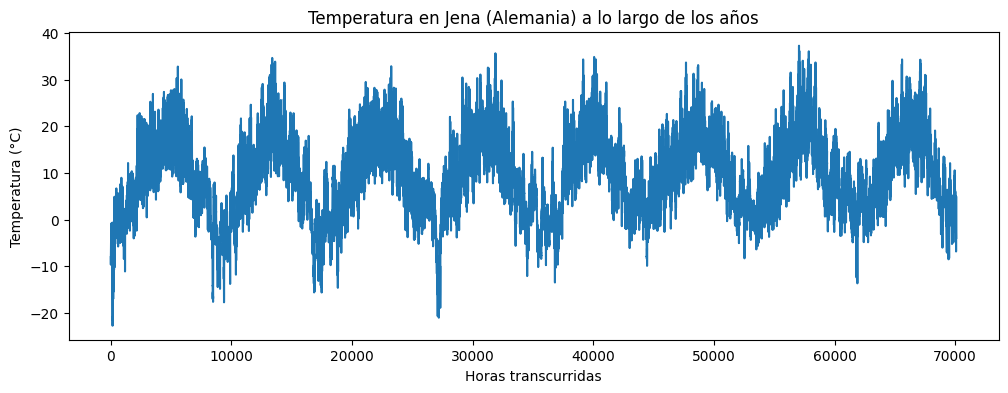

In [3]:
# 6. Carga y exploración de datos (descargamos el dataset y lo exploramos.)
# Descargamos el archivo zip (sin pedirle a TensorFlow que lo extraiga para evitar el error de la carpeta)
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip'
)

# Pandas puede leer archivos .zip de forma nativa indicando compression='zip'
df = pd.read_csv(zip_path, compression='zip')

# El dataset original tiene datos cada 10 minutos. Para que nuestro modelo entrene
# rápido en Colab, tomaremos un dato cada 6 posiciones (es decir, 1 dato por hora)
df = df[5::6]

# Veamos cómo es la temperatura a lo largo del tiempo
temperatura = df['T (degC)'].values # Extraemos solo la columna de temperatura

plt.figure(figsize=(12, 4))
plt.plot(temperatura)
plt.title('Temperatura en Jena (Alemania) a lo largo de los años')
plt.xlabel('Horas transcurridas')
plt.ylabel('Temperatura (°C)')
plt.show()

In [4]:
# 7. Preprocesamiento (preprocesamiento para series temporales: normalizar y crear las "ventanas temporales")

# 1. Normalización: Las redes neuronales sufren si los datos tienen valores muy grandes.
# Escalamos la temperatura entre 0 y 1.
scaler = MinMaxScaler(feature_range=(0, 1))
temp_scaled = scaler.fit_transform(temperatura.reshape(-1, 1))

# 2. Dividir en Entrenamiento y Prueba (80% / 20%)
# ¡Importante! En series temporales no mezclamos aleatoriamente. Respetamos el orden cronológico.
split_index = int(len(temp_scaled) * 0.8)
train_data = temp_scaled[:split_index]
test_data = temp_scaled[split_index:]

# 3. Crear ventanas temporales (Time Windows)
def crear_dataset(dataset, look_back=24):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        # Tomamos 'look_back' horas para X
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        # El valor Y es la temperatura de la hora siguiente
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Usaremos una ventana de 24 horas (usamos las últimas 24 hrs para predecir la siguiente)
look_back = 24
X_train, y_train = crear_dataset(train_data, look_back)
X_test, y_test = crear_dataset(test_data, look_back)

# Reshape para que sea compatible con LSTM [muestras, pasos de tiempo, características]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("Tamaño X_train:", X_train.shape)
print("Tamaño y_train:", y_train.shape)

Tamaño X_train: (56047, 24, 1)
Tamaño y_train: (56047,)


In [5]:
# 8. Modelo (Construimos nuestra red neuronal LSTM)
model = Sequential()

# Capa LSTM. input_shape=(24, 1) significa: veo 24 pasos de tiempo, con 1 característica (temperatura)
model.add(LSTM(32, input_shape=(look_back, 1)))

# Capa Densa de salida (solo 1 neurona, porque queremos predecir 1 valor continuo)
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 9. Entrenamiento
# Entrenamos el modelo. Como es una predicción de números exactos (regresión), usamos el Error Cuadrático Medio (MSE) en vez de Precisión (Accuracy).
# Usamos el optimizador Adam y medimos la pérdida con 'mse' (Mean Squared Error)
model.compile(optimizer='adam', loss='mse')

# Entrenamos el modelo. Usamos menos épocas y un batch grande para que Colab lo termine rápido
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=1)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0048 - val_loss: 0.0018
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9.2408e-04 - val_loss: 5.1505e-04
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.6779e-04 - val_loss: 3.8923e-04
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.8432e-04 - val_loss: 3.4842e-04
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.2443e-04 - val_loss: 2.7125e-04
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.7742e-04 - val_loss: 2.2764e-04
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.4248e-04 - val_loss: 3.6367e-04
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.2155e-04 - val_loss: 1.9040e-04
Epoch 9/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.0770e-04 - val_loss: 1.8082e-04
Epoch 10/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9091e-04 - val_loss: 1.8960e-04


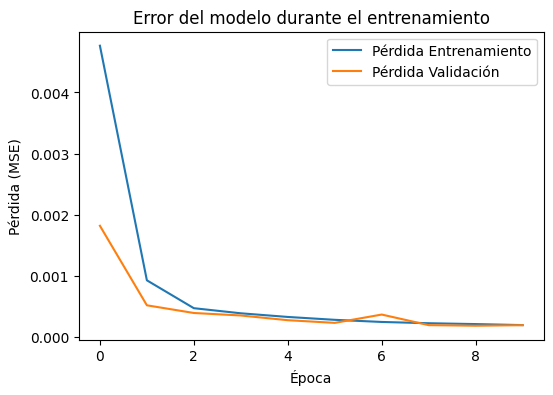

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
\nError Absoluto Medio (MAE): 0.60 °C
Error Cuadrático Medio (MSE): 0.68


In [7]:
# 10. Evaluación: Predicciones y Métricas (evaluamos)

# Gráfica de la pérdida (Error) durante el entrenamiento
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Error del modelo durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

# Hacemos las predicciones con el conjunto de test
predicciones = model.predict(X_test)

# Importante: Las predicciones están entre 0 y 1. Hay que hacer el proceso inverso (inverse_transform)
# para volver a verlas en Grados Centígrados reales.
pred_reales = scaler.inverse_transform(predicciones)
y_test_reales = scaler.inverse_transform(y_test.reshape(-1, 1))

# Cálculo de errores
mae = mean_absolute_error(y_test_reales, pred_reales)
mse = mean_squared_error(y_test_reales, pred_reales)

print(f"\\nError Absoluto Medio (MAE): {mae:.2f} °C")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")

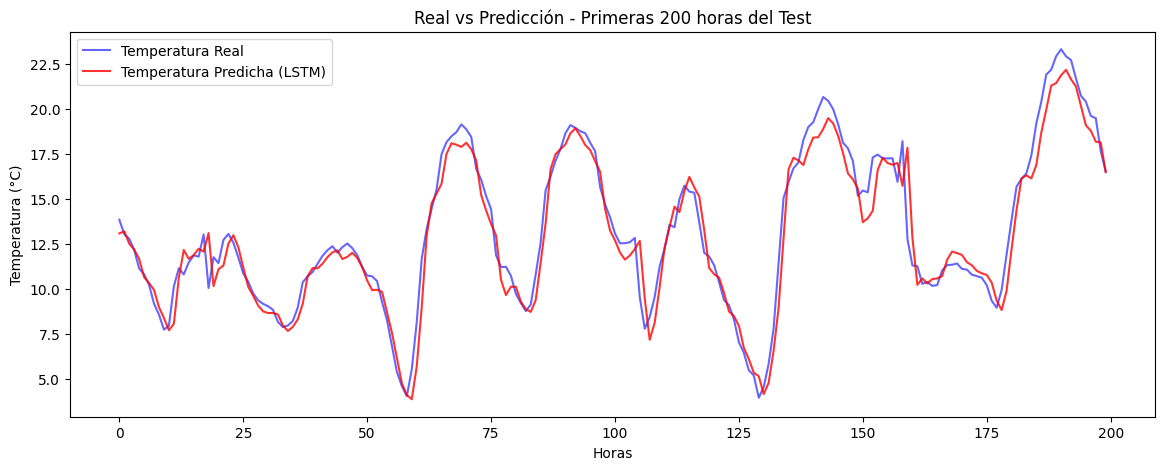

In [8]:
# Gráfica de valores reales vs predichos
# Vamos a graficar los resultados para ver si las líneas de lo real y lo predicho se solapan.
# Solo graficaremos una ventana de 200 horas para que se pueda apreciar el detalle
plt.figure(figsize=(14, 5))
plt.plot(y_test_reales[:200], label='Temperatura Real', color='blue', alpha=0.6)
plt.plot(pred_reales[:200], label='Temperatura Predicha (LSTM)', color='red', alpha=0.8)
plt.title('Real vs Predicción - Primeras 200 horas del Test')
plt.xlabel('Horas')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.show()

## 11. Conclusión
El modelo logró entrenarse exitosamente, y al observar la gráfica de "Real vs Predicción" notamos que la línea roja (predicción) persigue muy de cerca a la línea azul (datos reales). El **MAE** nos indica que en promedio, el modelo se equivoca por muy pocos grados centígrados en su predicción para la hora siguiente.

## 12. Qué aprendí
* **Evaluación del seguimiento de tendencia:** La LSTM sigue excelentemente la tendencia (las subidas y bajadas diarias por el día y la noche). Esto demuestra la capacidad teórica de la red recurrente: al tener "memoria" a través del estado oculto, sabe que si han pasado 24 horas (su ventana), la temperatura probablemente se comportará de manera similar al ciclo anterior.
* **Retraso temporal (Lag):** En este tipo de problemas univariantes (predecir el valor usando solo sus pasados), a veces se observa que el modelo hace una pequeña "sombra" del último valor conocido (un ligero retraso). Esto se corrige añadiendo más variables al modelo (multivariante), como la humedad, presión y hora del día.
* **Separación temporal:** Aprendí por qué no se usa `train_test_split` tradicional (que mezcla al azar) en series temporales. Si mezcláramos datos del futuro con el pasado, el modelo "haría trampa", por lo que cortamos cronológicamente en el índice 80%.